In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def get_residuals(filename):
    """get residual values from residuals file. 
       Output should be DataFrame with columns:
       coord1, ... , coord6, ab_initio_E, fit_E, residual 
       
       - filename the name of the residuals file (string)
       - Presumes res file is ordered in energy (first row lowest energy)
       - All res files should include the minimum point geometry
         as a first line."""
    
    with open(filename, 'r') as file:
        
        df_values = []
        line = file.readline()
        #skip unnecessary lines 
        while line[0] != ' ':
            line = file.readline()
        
        #append values for lines with residuals
        line_split = line.split()
        while len(line_split) != 0:
            
            #convert strings to values, build rows
            row = []
            for i in range(9):
                row.append(float(line_split[i]))
            df_values.append(row)
            
            #update line reading
            line = file.readline()
            line_split = line.split()
            
    return pd.DataFrame(df_values)


def plot_residuals(filename):
    """plots residuals from the input residuals file
       - filename the name of residuals file (string)"""
    
    #get residuals, shift energies 
    residuals_df = get_residuals(filename)
    residuals_df.loc[:, 6:7] = residuals_df.loc[:, 6:7] - residuals_df.loc[0, 6] 
    
    #ab initio energies (relative to minimum) and residuals
    ab_initio_E = residuals_df.loc[:, 6]
    residuals = residuals_df.loc[:, 8]

    #plot residuals
    fig, ax = plt.subplots(1,1, figsize=(12,7))
    plt.title('Full Picture', fontsize=15)
    ax.plot(ab_initio_E, residuals, '.')
    #fig.text(-0.02, 0.5, r'$\Delta E(calc - fit)$ $\:$ ($cm^{-1}$)'', va='center', rotation='horizontal', fontsize=12)
    ax.set_ylabel(r'$\Delta E(calc - fit)$ $\:$ ($cm^{-1}$)', 
                  fontsize=15)
    ax.set_xlabel(r'Relative Energy ($cm^{-1}$)', fontsize=15)
    ax.tick_params(labelsize=15)
    
    xlim = np.array((20000, 12000, 5000))
    ylim_low = ((-1000, -150, -25))
    ylim_high = np.array((550, 100, 10))
    fig2, ax2 = plt.subplots(3,1, figsize=(12,25))
    for i in range(3):
        ax2[i].plot(ab_initio_E, residuals, '.')
        ax2[i].set_xlim(0, xlim[i])
        ax2[i].set_ylim(ylim_low[i], ylim_high[i])
        ax2[i].set_ylabel(r'$\Delta E(calc - fit)$ $\:$ ($cm^{-1}$)', 
                  fontsize=15)
    ax2[2].set_xlabel(r'Relative Energy ($cm^{-1}$)', fontsize=15)
        

def plot_compare_residuals(test_file, fit_file, test_label, fit_label):
    """plot both the test residuals and fit residuals
       - test_file and fit_file the name of residuals files (string)"""
    #get residuals, shift energies 
    test_residuals_df = get_residuals(test_file)
    test_residuals_df.loc[:, 6:7] = test_residuals_df.loc[:, 6:7] - test_residuals_df.loc[0, 6] 
    fit_residuals_df = get_residuals(fit_file)
    fit_residuals_df.loc[:, 6:7] = fit_residuals_df.loc[:, 6:7] - fit_residuals_df.loc[0, 6] 
    
    #ab initio energies (relative to minimum) and residuals
    test_ab_initio_E = test_residuals_df.loc[:, 6]
    test_residuals = test_residuals_df.loc[:, 8]
    fit_ab_initio_E = fit_residuals_df.loc[:, 6]
    fit_residuals = fit_residuals_df.loc[:, 8]

    #plot residuals
    fig, ax = plt.subplots(1,1, figsize=(12,7))
    plt.title('Full Picture', fontsize=15)
    ax.plot(fit_ab_initio_E, fit_residuals, '.', color='blue', label=fit_label)
    ax.plot(test_ab_initio_E, test_residuals, '.', color='red', label=test_label)
    #fig.text(-0.02, 0.5, r'$\Delta E(calc - fit)$ $\:$ ($cm^{-1}$)'', va='center', rotation='horizontal', fontsize=12)
    ax.set_ylabel(r'$\Delta E(calc - fit)$ $\:$ ($cm^{-1}$)', 
                  fontsize=15)
    ax.set_xlabel(r'Relative Energy ($cm^{-1}$)', fontsize=15)
    ax.tick_params(labelsize=15)
    plt.legend(loc='best')
    
    xlim = np.array((20000, 12000, 5000))
    ylim_low = ((-1000, -150, -25))
    ylim_high = np.array((550, 100, 10))
    fig2, ax2 = plt.subplots(3,1, figsize=(12,25))
    for i in range(3):
        ax2[i].plot(fit_ab_initio_E, fit_residuals, '.', color='blue')
        ax2[i].plot(test_ab_initio_E, test_residuals, '.', color='red')
        ax2[i].set_xlim(0, xlim[i])
        ax2[i].set_ylim(ylim_low[i], ylim_high[i])
        ax2[i].set_ylabel(r'$\Delta E(calc - fit)$ $\:$ ($cm^{-1}$)', 
                  fontsize=15)
        ax2[i].set_title(f'Energy range (0 to {xlim[i]}' + r' $cm^{-1}$)',
                         fontsize=12)
    ax2[2].set_xlabel(r'Relative Energy ($cm^{-1}$)', fontsize=15)
    

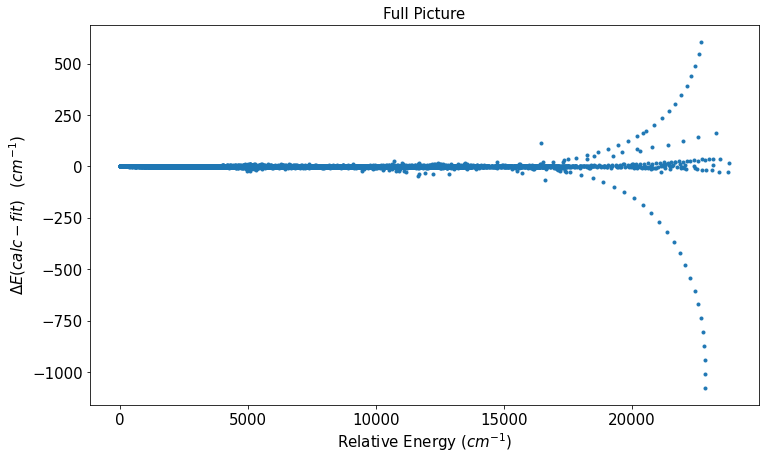

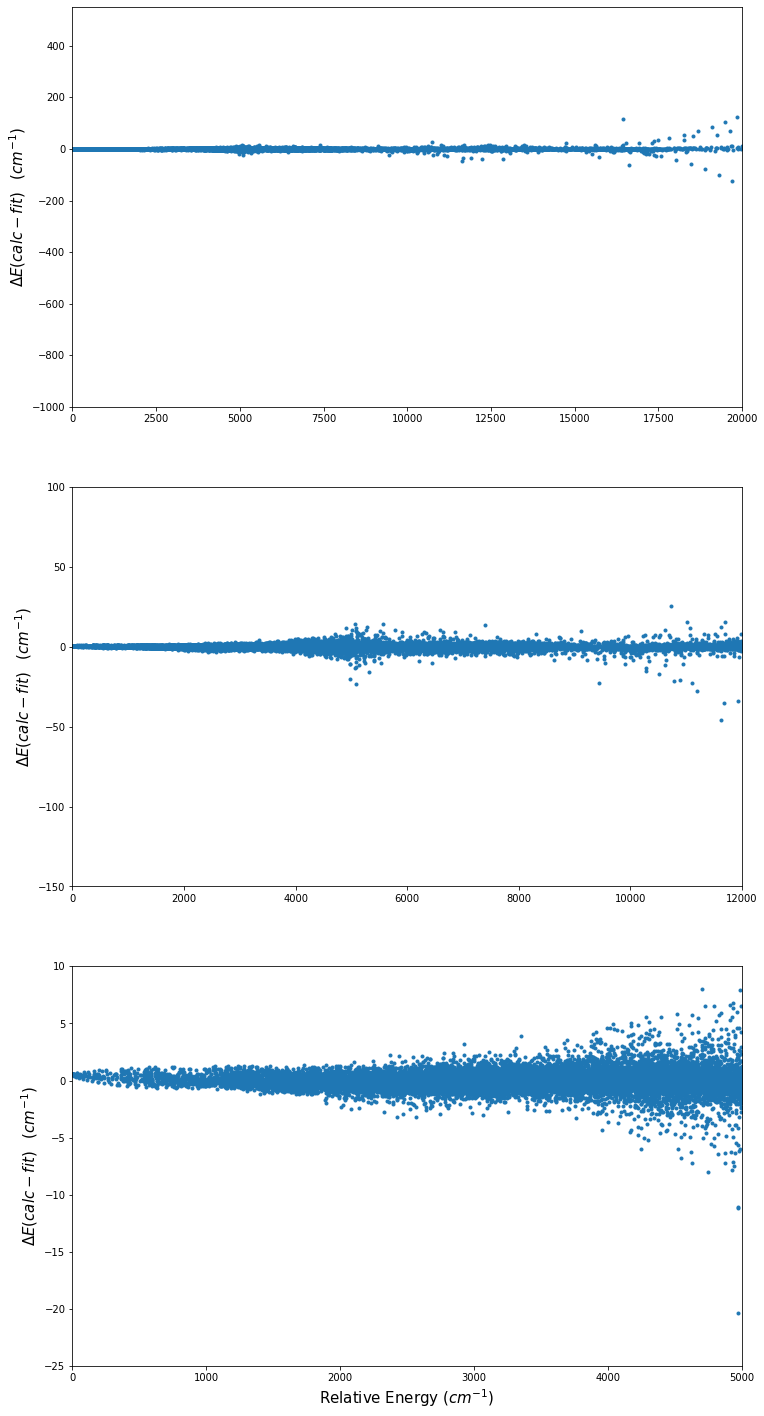

In [3]:
plot_residuals('6D_6.res')

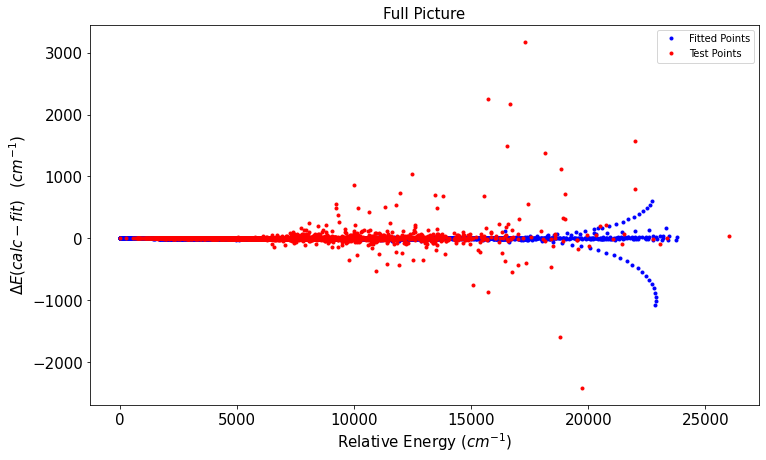

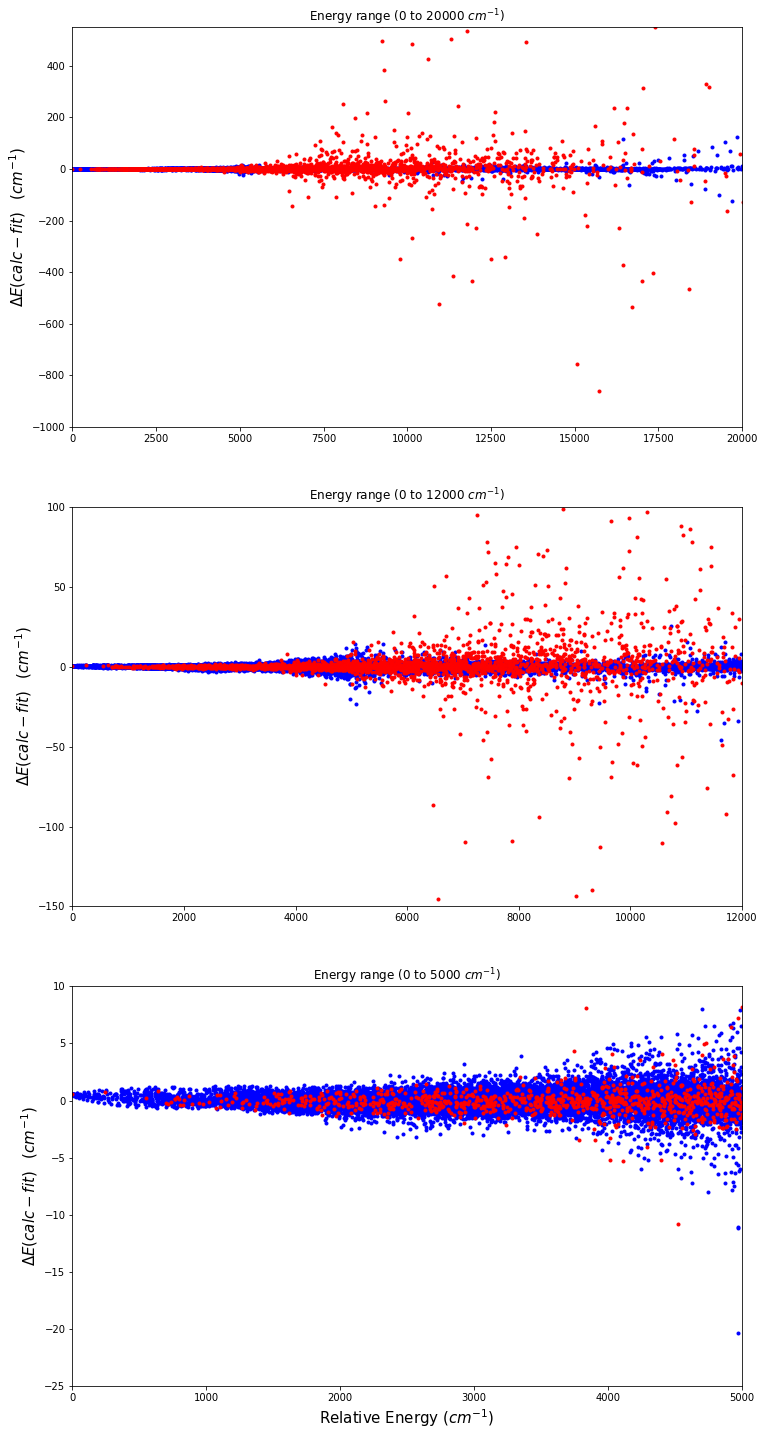

In [4]:
plot_compare_residuals('test_fit.res', '6D_6.res', 'Test Points', 'Fitted Points')

# Test points in Fit
- Note the red points are what was previously calculated in the residuals of the old fit
- In the blue, the test points are included within the fit, and clearly since no blue points are as far as red, have we significantly reduced the error (at least for the test points).

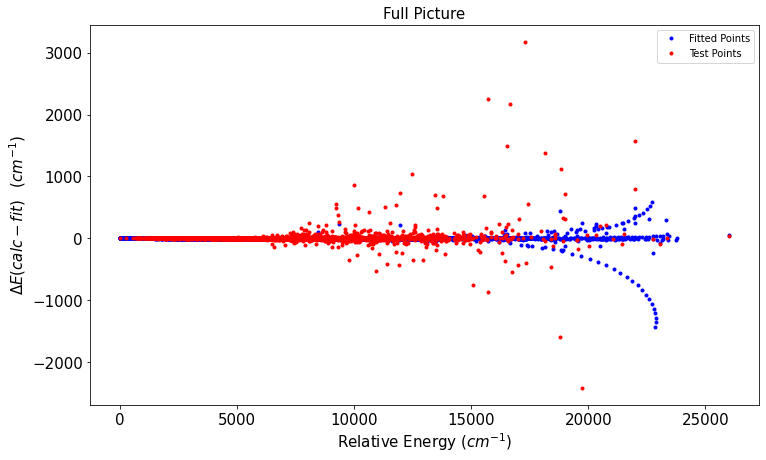

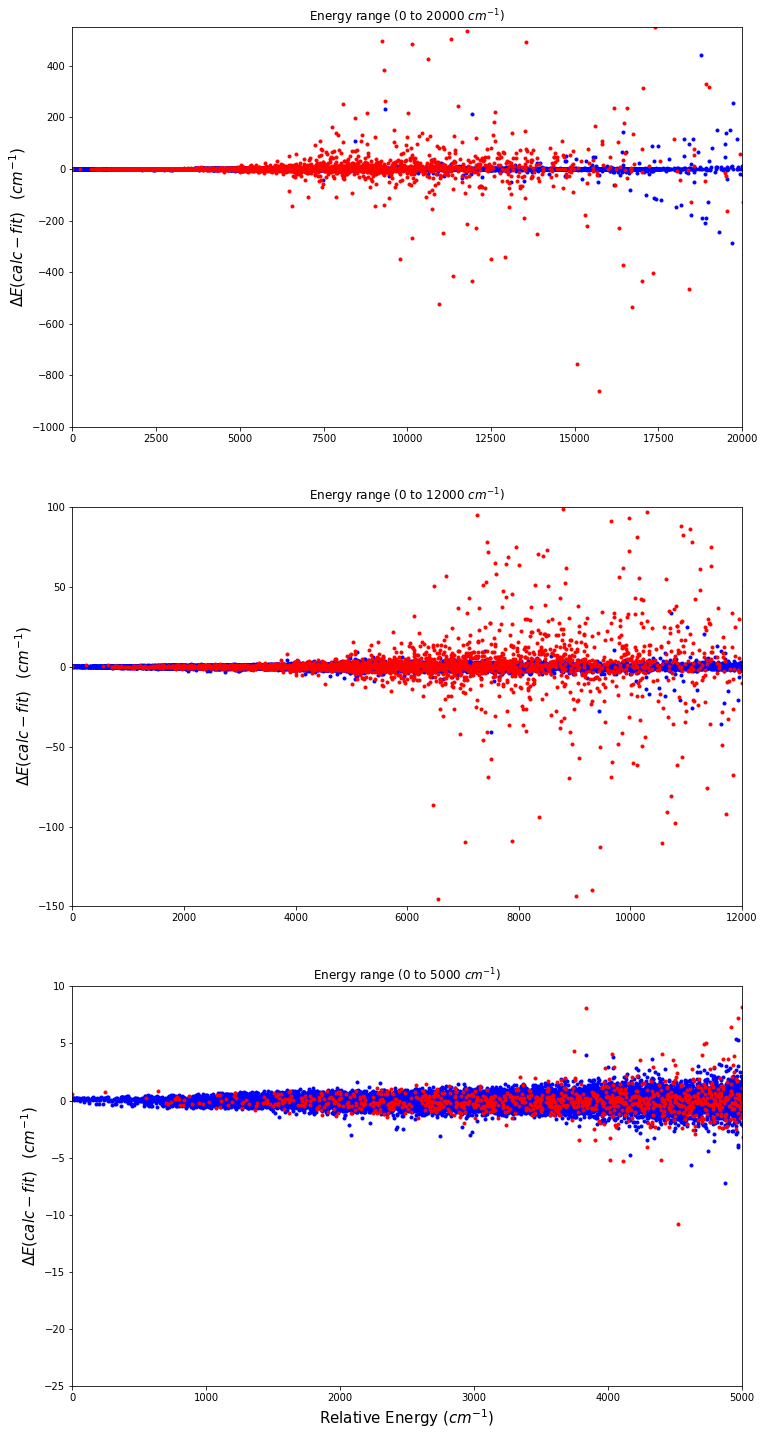

In [5]:
plot_compare_residuals('test_fit.res', '6D_7.res', 'Test Points', 'Fitted Points')